In [73]:
from pathlib import Path
from pprint import pprint
import pydicom
import pydicom_seg
import numpy as np

In [74]:
SEG_TYPES = [
    "T2 Weighted Axial Segmentations",
    "Apparent Diffusion Coefficient Segmentations",
    "DCE Subtraction Segmentations"
]

IMAGE_TYPES = [
    "T2 Weighted Axial",
    "Apparent Diffusion Coefficient",
    "DCE",
    "DWI"
]


In [75]:
class Patient:
    def __init__(self, studies, path):
        self.studies = studies # list of studies for each patient (2 in QIN-Prostate)
        self.path = path # path to patient (15 patients in QIN-Prostate)

class Study:
    def __init__(self, scans, path):
        self.scans = scans # (list of .dcm scans for each study for a given patient)
        self.path = path # path to scan (2 scans per patient)

class Scan:
    def __init__(self, type, data, path):
        self.type = type # description of type of scan (T2w, DCE, DWI, ADC)
        self.data = None # 3D/4D stacked volume of images, but not loaded until we call the load method on the path
        self.path = path # path to folder of these images
    
    def load(self):
        files = sorted(self.path.glob("*.dcm"))
        slices = [pydicom.dcmread(f) for f in files]
        
        # special handling for DCE because of temporal dimension
        if self.type == "DCE":
            slices.sort(key=lambda s: (int(s.TemporalPositionIdentifier), float(s.SliceLocation)))
            timepoints = {}
            for s in slices:
                t = s.TemporalPositionIdentifier
                timepoints.setdefault(t, []).append(s.pixel_array)
            self.data = np.stack([np.stack(timepoints[t]) for t in sorted(timepoints)])
        else:
            slices.sort(key=lambda s: float(s.SliceLocation))
            self.data = np.stack([s.pixel_array for s in slices])

    def load_segmentation(self):
        assert self.type in SEG_TYPES, f"load_segmentation() is for segmentation types only, got {self.type}"

        dcm_file = next(self.path.glob("*.dcm"))  # SEG is always a single file
        dcm = pydicom.dcmread(dcm_file)
        reader = pydicom_seg.SegmentReader()
        result = reader.read(dcm)

        # return dict of segment_number -> (Z, H, W) numpy array
        self.data = {
            segment_number: result.segment_data(segment_number)
            for segment_number in result.available_segments
        }
    
    def peak_enhancement_volume(self, seg_scan):
        assert self.type == "DCE", "peak_enhancement_volume() is only valid for DCE scans"
        assert self.data is not None, "call load() before peak_enhancement_volume()"
        assert seg_scan.type == "DCE Subtraction Segmentations", "seg_scan must be DCE Subtraction Segmentations"
        assert seg_scan.data is not None, "call load_segmentation() on seg_scan before peak_enhancement_volume()"

        # (Z, H, W) binary mask of whole gland
        whole_gland_mask = seg_scan.data[4].astype(bool)

        # apply mask to DCE data (T, Z, H, W)
        # mean over masked voxels only per timepoint
        mean_per_timepoint = np.array([
            self.data[t][whole_gland_mask].mean()
            for t in range(self.data.shape[0])
        ])

        peak_timepoint = np.argmax(mean_per_timepoint)
        return self.data[peak_timepoint, :, :, :]  # (Z, H, W)

In [76]:
# load all the data and populate the classes with relevant data
data_folder = Path("../datasets/QIN-PROSTATE-Repeatability_v2_20180510/qin_prostate_repeatability")

patients = []
desired_scans = ["T2 Weighted Axial", "DCE", "DWI", "Apparent Diffusion Coefficient"]

for patient_path in sorted(data_folder.glob("PCAMPMRI*")):
    studies = []
    for study_path in sorted(patient_path.iterdir()):
        if not study_path.is_dir(): continue
        scans = []
        for series_path in sorted(study_path.iterdir()):
            if not series_path.is_dir(): continue
            first_dcm = next(series_path.glob("*.dcm"), None)
            if first_dcm is None:
                continue
            ds = pydicom.dcmread(first_dcm, stop_before_pixels=True)
            scan_type = getattr(ds, "SeriesDescription", "Unknown")
            scans.append(Scan(scan_type, None, series_path))  # data=None for now
        studies.append(Study(scans, study_path))
    patients.append(Patient(studies, patient_path))


In [77]:
patient = patients[0]
study = patient.studies[0]

for scan in study.scans:
    if scan.type in SEG_TYPES:
        scan.load_segmentation()
        print(f"{scan.type}: {[f'segment {k}: {v.shape}' for k, v in scan.data.items()]}")
    elif scan.type in IMAGE_TYPES:
        scan.load()
        print(f"{scan.type}: {scan.data.shape}")

T2 Weighted Axial: (30, 512, 512)
Apparent Diffusion Coefficient: (20, 256, 256)
DCE Subtraction Segmentations: ['segment 1: (16, 256, 256)', 'segment 2: (16, 256, 256)', 'segment 3: (16, 256, 256)', 'segment 4: (16, 256, 256)']
T2 Weighted Axial Segmentations: ['segment 1: (30, 512, 512)', 'segment 2: (30, 512, 512)', 'segment 3: (30, 512, 512)', 'segment 4: (30, 512, 512)']
DCE: (54, 16, 256, 256)
Apparent Diffusion Coefficient Segmentations: ['segment 1: (20, 256, 256)', 'segment 2: (20, 256, 256)', 'segment 3: (20, 256, 256)', 'segment 4: (20, 256, 256)']
DWI: (40, 256, 256)


In [78]:
seg_scan = next(scan for scan in study.scans if scan.type == "T2 Weighted Axial Segmentations")
dcm = pydicom.dcmread(next(seg_scan.path.glob("*.dcm")))
reader = pydicom_seg.SegmentReader()
result = reader.read(dcm)

for segment_number in result.available_segments:
    desc = result.segment_infos[segment_number].SegmentDescription
    print(f"segment {segment_number}: {desc}")

segment 1: NormalROI_PZ_1
segment 2: PeripheralZone
segment 3: TumorROI_PZ_1
segment 4: WholeGland


peak timepoint shape: (16, 256, 256)


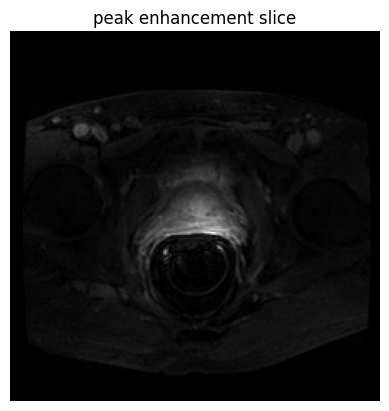

In [79]:
dce_scan = next(scan for scan in study.scans if scan.type == "DCE")
seg_scan = next(scan for scan in study.scans if scan.type == "DCE Subtraction Segmentations")

peak_volume = dce_scan.peak_enhancement_volume(seg_scan)
print(f"peak timepoint shape: {peak_volume.shape}")

# visualize middle slice of peak volume
plt.imshow(peak_volume[peak_volume.shape[0] // 2], cmap="gray")
plt.title("peak enhancement slice")
plt.axis("off")
plt.show()

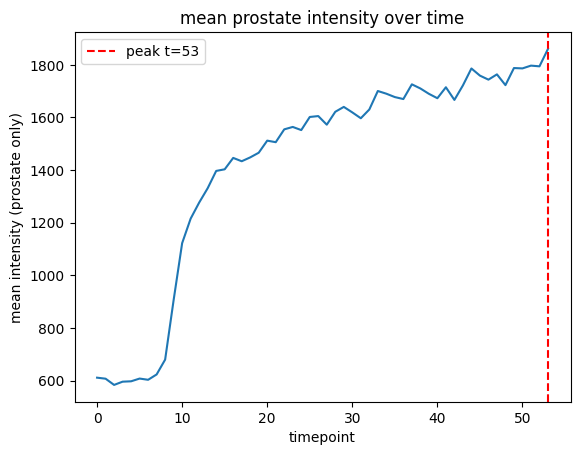

In [80]:
whole_gland_mask = seg_scan.data[4].astype(bool)
mean_per_timepoint = np.array([
    dce_scan.data[t][whole_gland_mask].mean()
    for t in range(dce_scan.data.shape[0])
])

plt.plot(mean_per_timepoint)
plt.xlabel("timepoint")
plt.ylabel("mean intensity (prostate only)")
plt.title("mean prostate intensity over time")
plt.axvline(np.argmax(mean_per_timepoint), color='r', linestyle='--', label=f"peak t={np.argmax(mean_per_timepoint)}")
plt.legend()
plt.show()